## Burnout-Driven Job Switching Prediction

This project uses a synthetic dataset sourced from Kaggle to analyse employee mental health and identify key factors influencing job-switching behaviour (employee churn) within the tech industry. The dataset includes demographic, work-related, and psychological attributes across various job roles.

## Problem statement
The primary objective is to predict whether an employee is likely to switch jobs based on indicators such as burnout, stress, work conditions, and organisational factors.

To enable this, a new binary target variable will_switch was engineered using domain-informed conditions, including:

* Low job satisfaction and work-life balance
* Moderate to high burnout levels
* High overtime workload
* Employment in startup environments

This transformation converts the problem into a supervised binary classification task.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [2]:
file=pd.read_csv("tech_mental_health_burnout.csv")
df=pd.DataFrame(file)
df.head(5)

,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
0,50,Female,Backend Developer,7.8,Large,Hybrid,45.0,0.0,5.0,0,...,8.6,1,4.4,0,4.8,4.3,2.6,1.0,Low,0
1,36,Male,Frontend Developer,1.8,Mid-size,Remote,56.0,4.0,6.0,0,...,11.5,4,4.1,0,6.7,4.8,4.6,3.7,Moderate,0
2,29,Male,DevOps,2.5,MNC,Hybrid,43.0,2.0,6.0,3,...,6.8,3,6.5,0,4.5,4.0,2.5,1.0,Low,0
3,42,Female,Backend Developer,1.5,Mid-size,Hybrid,57.0,9.0,4.0,1,...,10.2,5,2.5,0,6.1,5.8,1.8,3.6,Moderate,0
4,40,Female,Frontend Developer,3.4,Large,Remote,49.0,0.0,3.0,4,...,11.9,5,4.6,0,7.2,5.9,2.4,3.5,Low,0


## Data Preperation

The following preprocessing steps were applied:

* Feature selection based on relevance to employee behaviour and mental health
* Categorical encoding (one-hot encoding) for variables such as job role, work mode, and company size
* Train-validation-test split to ensure robust and unbiased model evaluation
* Feature scaling for numerical variables to support model performance

In [3]:
df.shape

(150000, 25)

In [4]:
pivot_df = df.pivot_table(index=['age','gender'],columns='company_size', aggfunc='size', fill_value=0)
print(pivot_df)

company_size    Large  MNC  Mid-size  Startup
age gender                                   
22  Female        445  441       480      460
    Male          598  655       630      609
    Non-binary     67   53        56       44
23  Female        466  465       447      431
    Male          653  669       581      649
...               ...  ...       ...      ...
53  Male          665  579       659      577
    Non-binary     52   57        68       68
54  Female        461  477       417      462
    Male          624  642       633      628
    Non-binary     58   63        60       48

[99 rows x 4 columns]


In [5]:
df.isna().sum()

age                        0
gender                     0
job_role                   0
experience_years           0
company_size               0
work_mode                  0
work_hours_per_week        0
overtime_hours             0
meetings_per_day           0
deadlines_missed           0
job_satisfaction           0
manager_support            0
work_life_balance          0
sleep_hours                0
physical_activity_days     0
screen_time_hours          0
caffeine_intake            0
social_support_score       0
has_therapy                0
stress_level               0
anxiety_score              0
depression_score           0
burnout_score              0
burnout_level              0
seeks_professional_help    0
dtype: int64

In [6]:
df.dtypes

age                          int64
gender                      object
job_role                    object
experience_years           float64
company_size                object
work_mode                   object
work_hours_per_week        float64
overtime_hours             float64
meetings_per_day           float64
deadlines_missed             int64
job_satisfaction           float64
manager_support            float64
work_life_balance          float64
sleep_hours                float64
physical_activity_days       int64
screen_time_hours          float64
caffeine_intake              int64
social_support_score       float64
has_therapy                  int64
stress_level               float64
anxiety_score              float64
depression_score           float64
burnout_score              float64
burnout_level               object
seeks_professional_help      int64
dtype: object

In [7]:
df[df["experience_years"]>df["age"]]

,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help


In [8]:
df[df.duplicated()]

,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help


In [9]:
for cols in df.columns:
    print("Column Name",cols)
    print(df[cols].unique())

Column Name age
[50 36 29 42 40 44 32 45 24 43 23 51 54 33 46 48 49 37 28 30 39 25 35 47
 41 38 27 31 52 22 26 34 53]
Column Name gender
['Female' 'Male' 'Non-binary']
Column Name job_role
['Backend Developer' 'Frontend Developer' 'DevOps' 'Data Scientist'
 'Software Engineer' 'Product Manager' 'QA Engineer' 'ML Engineer']
Column Name experience_years
[ 7.8  1.8  2.5  1.5  3.4 10.8  1.6  9.1  6.5  7.1  8.5  6.8 11.6  8.1
  5.1  4.6  8.4  6.9  0.5  4.9  5.5  9.2  3.7  6.2  4.2  7.6  1.2  3.6
  0.   4.4  7.3  4.5  1.9  3.9  5.   2.4  5.7  0.6  3.3  7.5  6.1  7.9
  8.2  5.6 14.9  9.9 12.8  3.5  5.4 13.8 11.   6.3  8.9  9.7 11.9 10.1
  2.1  4.7 10.6 10.7  2.8  1.1  6.   7.2  7.7  4.   2.6  0.9  8.7  0.4
  2.3  9.6 10.9 13.   9.4  2.7  5.9  3.8  8.6 12.1  5.2  4.3  0.7  3.
  8.8  5.3  8.3  2.9 11.2 13.2  8.   3.2  9.5  7.4  6.4 14.1 11.5  1.
  4.8  4.1  3.1  0.1  2.2  9.3  6.7 10.5  5.8  0.3 10.3 10.2  0.8  0.2
  1.3  7.   1.7  9.8  1.4  6.6 11.3  2.  10.  11.8 11.4 11.7 12.9  9.
 11.1 14.6

In [10]:
df["work_hours_per_week"].value_counts()

work_hours_per_week
47.0    7663
46.0    7498
48.0    7365
45.0    7290
49.0    7196
50.0    6949
44.0    6826
43.0    6584
51.0    6581
42.0    6259
52.0    6147
41.0    5709
53.0    5549
40.0    5038
54.0    4982
39.0    4585
55.0    4499
56.0    4009
38.0    3941
37.0    3426
57.0    3401
30.0    2978
58.0    2914
36.0    2886
35.0    2475
59.0    2382
34.0    2090
60.0    1938
61.0    1572
33.0    1567
32.0    1330
62.0    1283
31.0    1065
63.0    1048
64.0     795
65.0     632
66.0     449
67.0     347
68.0     226
69.0     180
70.0     125
71.0      76
72.0      45
73.0      35
74.0      33
75.0       8
76.0       7
77.0       6
79.0       6
78.0       3
81.0       1
84.0       1
Name: count, dtype: int64

In [11]:
df["work_hours_per_week"].describe()

count    150000.00000
mean         47.00758
std           7.89331
min          30.00000
25%          42.00000
50%          47.00000
75%          52.00000
max          84.00000
Name: work_hours_per_week, dtype: float64

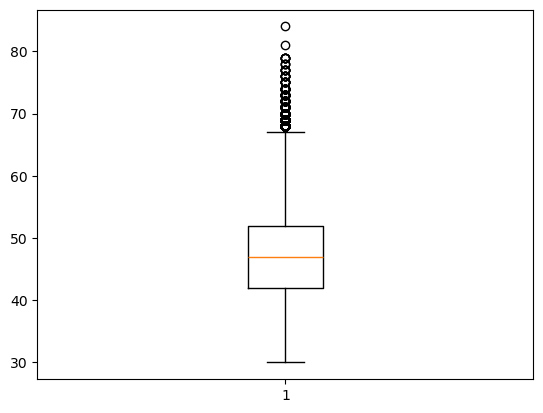

In [12]:
plt.boxplot(df["work_hours_per_week"])
plt.show()

In [13]:
df[(df["work_hours_per_week"]>65)&(df["overtime_hours"]>0)]

,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
334,54,Female,Backend Developer,5.9,Large,Remote,66.0,6.0,6.0,1,...,9.4,0,2.9,0,6.2,4.1,3.8,2.2,Low,0
372,50,Female,Data Scientist,9.4,Startup,Remote,66.0,9.0,5.0,0,...,8.1,3,7.9,0,9.5,5.1,4.2,4.6,Moderate,0
595,24,Male,Software Engineer,5.3,Startup,Remote,66.0,9.0,5.0,3,...,6.3,4,6.0,0,6.8,5.8,2.8,3.1,Low,1
607,22,Female,Backend Developer,6.5,MNC,Hybrid,66.0,1.0,5.0,1,...,7.6,1,8.3,0,5.2,2.5,2.4,1.0,Low,0
621,29,Female,QA Engineer,6.0,Large,Remote,66.0,2.0,0.0,1,...,9.8,2,5.0,0,8.8,6.2,6.1,5.7,Moderate,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149540,44,Male,Frontend Developer,7.5,MNC,Hybrid,66.0,2.0,7.0,0,...,10.2,1,6.4,0,5.3,3.3,2.1,1.6,Low,0
149719,36,Male,Frontend Developer,1.6,Mid-size,Remote,66.0,9.0,5.0,5,...,8.4,3,4.6,1,4.8,3.6,1.7,1.1,Low,0
149812,33,Male,Backend Developer,5.9,MNC,Hybrid,66.0,9.0,0.0,1,...,8.7,1,3.8,0,7.7,6.3,5.0,5.4,Moderate,0
149841,34,Male,Backend Developer,0.0,Startup,Remote,69.0,8.0,4.0,3,...,7.4,4,7.3,0,7.7,4.3,3.7,4.3,Moderate,0


In [14]:
df[(df["work_hours_per_week"]>65)&(df["overtime_hours"]>0)&(df["manager_support"]<5)]

,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
372,50,Female,Data Scientist,9.4,Startup,Remote,66.0,9.0,5.0,0,...,8.1,3,7.9,0,9.5,5.1,4.2,4.6,Moderate,0
595,24,Male,Software Engineer,5.3,Startup,Remote,66.0,9.0,5.0,3,...,6.3,4,6.0,0,6.8,5.8,2.8,3.1,Low,1
621,29,Female,QA Engineer,6.0,Large,Remote,66.0,2.0,0.0,1,...,9.8,2,5.0,0,8.8,6.2,6.1,5.7,Moderate,0
733,35,Female,Software Engineer,6.6,MNC,Remote,66.0,9.0,3.0,0,...,8.6,1,3.4,0,6.4,6.2,3.9,4.1,Moderate,1
904,37,Male,Product Manager,3.9,MNC,Onsite,67.0,3.0,5.0,4,...,12.0,4,4.6,0,8.4,6.0,6.6,6.5,Moderate,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148904,29,Female,Frontend Developer,1.8,MNC,Remote,75.0,6.0,2.0,1,...,8.0,3,3.9,0,9.9,6.9,6.8,5.3,Moderate,1
149258,41,Female,Data Scientist,0.0,Startup,Remote,68.0,5.0,4.0,0,...,8.8,2,3.8,1,6.7,6.1,3.8,4.5,Moderate,0
149304,49,Male,Backend Developer,8.2,Mid-size,Onsite,70.0,5.0,6.0,0,...,7.2,1,7.1,0,5.2,3.2,1.4,2.8,Low,0
149812,33,Male,Backend Developer,5.9,MNC,Hybrid,66.0,9.0,0.0,1,...,8.7,1,3.8,0,7.7,6.3,5.0,5.4,Moderate,0


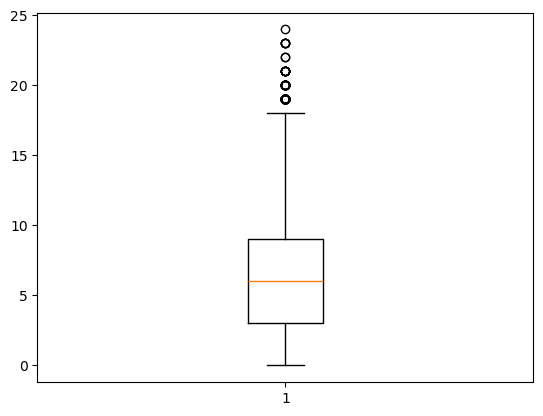

In [15]:
plt.boxplot(df["overtime_hours"])
plt.show()

In [16]:
df["overtime_hours"].describe()

count    150000.000000
mean          6.127180
std           3.783618
min           0.000000
25%           3.000000
50%           6.000000
75%           9.000000
max          24.000000
Name: overtime_hours, dtype: float64

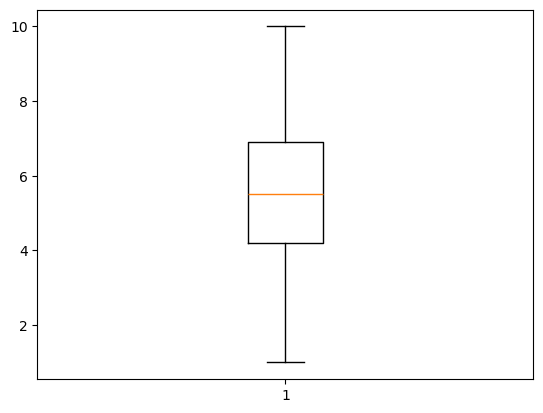

In [17]:
plt.boxplot(df["job_satisfaction"])
plt.show()

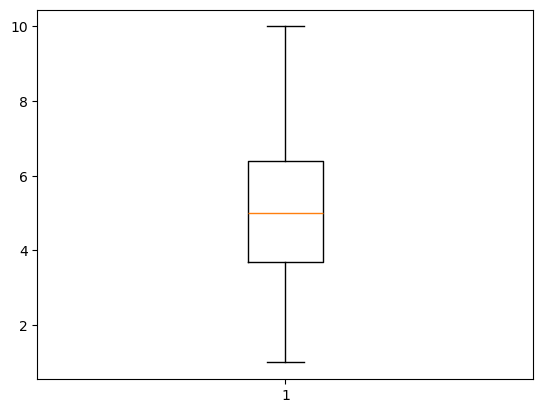

In [18]:
plt.boxplot(df["work_life_balance"])
plt.show()

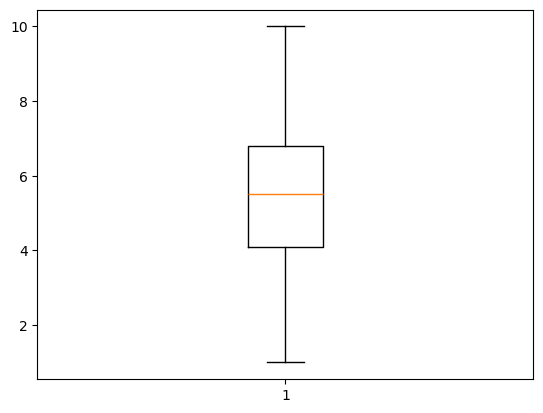

In [19]:
plt.boxplot(df["manager_support"])
plt.show()

In [35]:
df['will_switch'] = ((
        (df['job_satisfaction'] < 5) &
        (df['work_life_balance'] < 5) &
        (df['burnout_level'].isin(['Moderate', 'High'])) &
        (df['overtime_hours'] > 6)
    ) |
    (df['company_size'] == 'Startup')).astype(int)

In [36]:
df["will_switch"].value_counts() #class imbalance present

will_switch
0    109543
1     40457
Name: count, dtype: int64

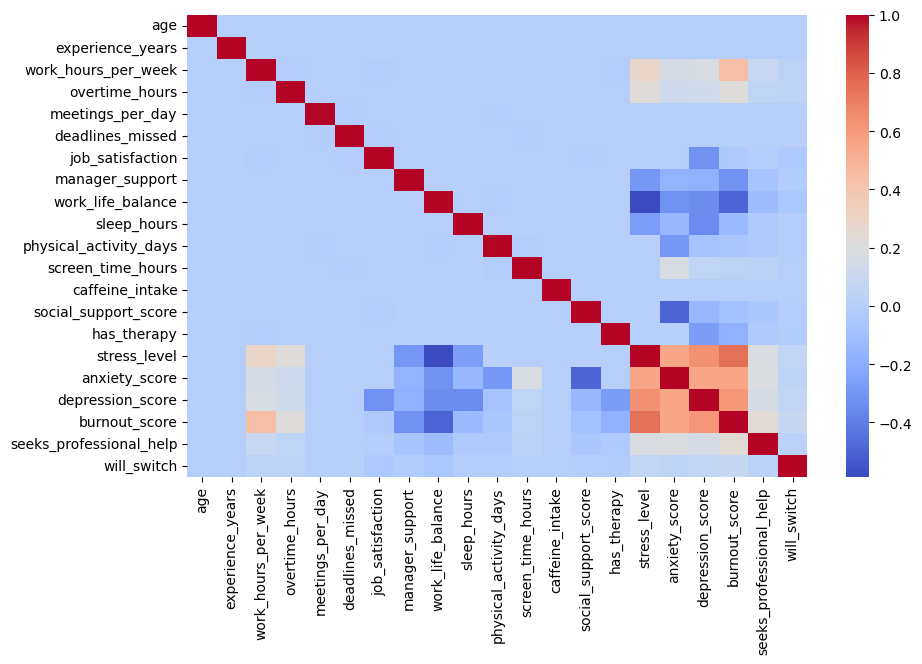

In [37]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.show()

In [38]:
df.groupby("job_role").size()

job_role
Backend Developer     18079
Data Scientist        22442
DevOps                14897
Frontend Developer    17967
ML Engineer           18153
Product Manager       11925
QA Engineer            8914
Software Engineer     37623
dtype: int64

In [39]:
df.groupby("job_role")["will_switch"].mean().round(2)

job_role
Backend Developer     0.27
Data Scientist        0.27
DevOps                0.27
Frontend Developer    0.28
ML Engineer           0.27
Product Manager       0.26
QA Engineer           0.27
Software Engineer     0.27
Name: will_switch, dtype: float64

In [50]:
X = df[[
    'burnout_score',
    'stress_level',
    'anxiety_score',
    'depression_score',
    'sleep_hours',
    'screen_time_hours',
    'physical_activity_days',
    'social_support_score',
    'deadlines_missed',
    'meetings_per_day',
    'experience_years',
    'age',
    'overtime_hours',          
    'company_size',            
    'work_mode',
    'job_role'
]]

In [51]:
X = pd.get_dummies(X, columns=['work_mode', 'job_role','company_size'], drop_first=True)

In [52]:
y=df["will_switch"]

In [53]:
X_train,X_temp,y_train,y_temp=train_test_split(X,y, test_size=0.4,stratify=y,random_state=42)
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=0.5,stratify=y_temp,random_state=42)

## Model Development

A Logistic Regression model was developed as a baseline due to its:

* Interpretability
* Efficiency on structured data
* Ability to provide probabilistic outputs

The model was further improved through:

* Hyperparameter tuning (regularisation strength and class weights)
* Handling class imbalance
* Decision threshold optimisation to balance precision and recall

## Evaluation Strategy

Model performance was evaluated using:

* Precision, Recall, and F1-score (with emphasis on identifying potential switchers)
* Confusion Matrix to analyse prediction errors
* ROC-AUC Score for overall model discrimination ability

In [54]:
log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [55]:
y_pred=log_model.predict(X_temp)
y_prob = log_model.predict_proba(X_temp)[:, 1]

In [56]:
print(classification_report(y_temp, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     43817
           1       0.95      0.96      0.95     16183

    accuracy                           0.97     60000
   macro avg       0.97      0.97      0.97     60000
weighted avg       0.97      0.97      0.97     60000



In [57]:
cm = confusion_matrix(y_temp, y_pred)
print(cm)

[[42937   880]
 [  680 15503]]


In [58]:
roc = roc_auc_score(y_temp, y_prob)
print("ROC-AUC:", roc)

ROC-AUC: 0.9975972489074812


In [59]:
# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

Best Parameters: {'model__C': 0.01, 'model__class_weight': {0: 1, 1: 1}, 'model__penalty': 'l2'}

=== Validation Results ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     21908
           1       0.99      0.93      0.96      8092

    accuracy                           0.98     30000
   macro avg       0.98      0.97      0.97     30000
weighted avg       0.98      0.98      0.98     30000

Confusion Matrix:
[[21846    62]
 [  541  7551]]
ROC-AUC Score: 0.9973178460936405

=== Test Results ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     21909
           1       0.99      0.94      0.96      8091

    accuracy                           0.98     30000
   macro avg       0.98      0.97      0.98     30000
weighted avg       0.98      0.98      0.98     30000

Confusion Matrix (Test):
[[21851    58]
 [  507  7584]]
ROC-AUC Score (Test): 0.9978397007489079

Top Positive Featu

In [ ]:
# -------------------------------
# Step 5: Hyperparameter tuning
# -------------------------------
param_grid = {
    'model__C': [0.01, 0.1, 1, 5, 10],
    'model__penalty': ['l2'],
    'model__class_weight': [
        {0:1, 1:1},
        {0:1, 1:1.5},
        {0:1, 1:2},
        {0:1, 1:2.5}
    ]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1',   # 🔥 balances precision + recall
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

In [ ]:
# -------------------------------
# Step 6: Validation Evaluation
# -------------------------------
best_model = grid.best_estimator_

y_prob = best_model.predict_proba(X_val)[:, 1]

# 🔥 Threshold tuning (IMPORTANT)
threshold = 0.5   # try 0.45–0.6

y_pred = (y_prob > threshold).astype(int)

print("\n=== Validation Results ===")
print(classification_report(y_val, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_val, y_prob))

In [ ]:
# -------------------------------
# Step 7: Test Evaluation
# -------------------------------
y_prob_test = best_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test > threshold).astype(int)

print("\n=== Test Results ===")
print(classification_report(y_test, y_pred_test))
print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test))
print("ROC-AUC Score (Test):", roc_auc_score(y_test, y_prob_test))

To interpret the model and understand key drivers of employee switching behaviour, feature importance was analysed using Logistic Regression coefficients.

Model coefficients were extracted and mapped to their corresponding features
Features with positive coefficients indicate a higher likelihood of job switching
Features with negative coefficients indicate factors that reduce switching likelihood

The top contributing features were identified by sorting coefficients in descending order, providing insights into:

Key risk factors driving employee churn
Protective factors associated with employee retention

This step enhances the interpretability of the model, making the results more actionable for decision-making.

In [ ]:
# -------------------------------
# Step 8: Feature Importance
# -------------------------------
model = best_model.named_steps['model']
feature_names = X.columns

coefficients = pd.Series(model.coef_[0], index=feature_names)
coefficients = coefficients.sort_values(ascending=False)

print("\nTop Positive Features (increase switching):")
print(coefficients.head(10))

print("\nTop Negative Features (reduce switching):")
print(coefficients.tail(10))

The final model provides both predictive capability and interpretability, enabling organisations to:

* Identify employees at risk of switching
* Understand the underlying factors influencing churn
* Support data-driven strategies for employee retention and well-being